**Câu 5:** Sử dụng thuật toán K-means để phân loại các cầu thủ thành các nhóm có chỉ số tương tự nhau.

1. Theo bạn thì nên phân loại cầu thủ thành bao nhiêu nhóm? Vì sao (gợi ý: sử dụng biểu đồ Elbow và Silhouette, vẽ 2 biểu đồ này)? Bạn có nhận xét gì về kết quả?
2. Sử dụng thuật toán PCA, giảm số chiều dữ liệu xuống 2 chiều, 3 chiều, vẽ hình scatter plot phân cụm các điểm dữ liệu trên mặt 2D và khối 3D.

Phương pháp
- Ghép các file dữ liệu cầu thủ: `stats.csv`, `shooting.csv`, `miscellaneous.csv`, `playingtime.csv`
- Lọc cầu thủ ngoài sân và cầu thủ thi đấu đủ số phút
- Chọn tiêu chí phân cụm hợp lý
- Chuẩn hóa dữ liệu
- Tìm số cụm bằng Elbow và Silhouette
- Chạy KMeans
- Trực quan hóa bằng PCA 2D và PCA 3D
- Phân tích đặc điểm từng cụm
- Xuất kết quả ra file CSV


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

RANDOM_STATE = 42

## 1. Đọc dữ liệu

In [16]:
stats = pd.read_csv("D:/PTIT/Kì 2 năm 2/Python/btl-python/SOURCE CODE/data/stats.csv")
shooting = pd.read_csv("D:/PTIT/Kì 2 năm 2/Python/btl-python/SOURCE CODE/data/shooting.csv")
misc = pd.read_csv("D:/PTIT/Kì 2 năm 2/Python/btl-python/SOURCE CODE/data/miscellaneous.csv")
playingtime = pd.read_csv("D:/PTIT/Kì 2 năm 2/Python/btl-python/SOURCE CODE/data/playingtime.csv")

print("stats:", stats.shape)
print("shooting:", shooting.shape)
print("miscellaneous:", misc.shape)
print("playingtime:", playingtime.shape)

display(stats.head())

stats: (546, 25)
shooting: (546, 19)
miscellaneous: (546, 21)
playingtime: (687, 25)


,Rk,Player,Nation,Pos,Squad,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G+A,Performance_G-PK,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Matches
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,25-205,2000,35,28,2301,25.6,4,5,9,4,0,0,2,0,0.16,0.20,0.35,0.16,0.35,Matches
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,20-002,2006,3,2,164,1.8,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
2,3,Tammy Abraham,eng ENG,FW,Aston Villa,28-225,1997,12,2,286,3.2,2,0,2,2,0,0,0,0,0.63,0.00,0.63,0.63,0.63,Matches
3,4,Joshua Acheampong,eng ENG,DF,Chelsea,20-010,2006,15,7,587,6.5,1,0,1,1,0,0,1,0,0.15,0.00,0.15,0.15,0.15,Matches
4,5,Tyler Adams,us USA,MF,Bournemouth,27-090,1999,23,19,1593,17.7,2,2,4,2,0,0,7,0,0.11,0.11,0.23,0.11,0.23,Matches


## 2. Làm sạch dữ liệu và ghép bảng

Các bảng được ghép theo thông tin định danh cầu thủ gồm: `Player`, `Nation`, `Pos`, `Squad`, `Age`, `Born`.


In [17]:
def clean_common(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    key_cols = ["Player", "Nation", "Pos", "Squad", "Age", "Born"]
    for col in key_cols:
        if col not in df.columns:
            df[col] = np.nan

    df["Player"] = df["Player"].astype(str).str.strip()
    df["Squad"] = df["Squad"].astype(str).str.strip()
    df["Pos"] = df["Pos"].astype(str).str.strip()

    return df


stats = clean_common(stats)
shooting = clean_common(shooting)
misc = clean_common(misc)
playingtime = clean_common(playingtime)

key_cols = ["Player", "Nation", "Pos", "Squad", "Age", "Born"]

df = stats.merge(
    shooting.drop(columns=["Rk", "Matches"], errors="ignore"),
    on=key_cols,
    how="left",
    suffixes=("", "_shooting")
)

df = df.merge(
    misc.drop(columns=["Rk", "Matches"], errors="ignore"),
    on=key_cols,
    how="left",
    suffixes=("", "_misc")
)

df = df.merge(
    playingtime.drop(columns=["Rk", "Matches"], errors="ignore"),
    on=key_cols,
    how="left",
    suffixes=("", "_playing")
)

df = df.loc[:, ~df.columns.duplicated()]

print("Kích thước dữ liệu sau khi ghép:", df.shape)
display(df.head())

Kích thước dữ liệu sau khi ghép: (546, 66)


,Rk,Player,Nation,Pos,Squad,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G+A,Performance_G-PK,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Matches,90s,Standard_Gls,Standard_Sh,Standard_SoT,Standard_SoT%,Standard_Sh/90,Standard_SoT/90,Standard_G/Sh,Standard_G/SoT,Standard_PK,Standard_PKatt,90s_misc,Performance_CrdY_misc,Performance_CrdR_misc,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_PKcon,Performance_OG,Playing Time_MP_playing,Playing Time_Min_playing,Playing Time_Mn/MP,Playing Time_Min%,Playing Time_90s_playing,Starts_Starts,Starts_Mn/Start,Starts_Compl,Subs_Subs,Subs_Mn/Sub,Subs_unSub,Team Success_PPM,Team Success_onG,Team Success_onGA,Team Success_+/-,Team Success_+/-90,Team Success_On-Off
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,25-205,2000,35,28,2301,25.6,4,5,9,4,0,0,2,0,0.16,0.20,0.35,0.16,0.35,Matches,25.6,4,43,16,37.2,1.68,0.63,0.09,0.25,0,0,25.6,2,0,0,19,50,5,37,17,26,NaN,NaN,0,35,2301.0,66.0,71.0,25.6,28,77.0,2,7,21.0,1,1.17,35.0,29.0,6.0,0.23,1.29
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,20-002,2006,3,2,164,1.8,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches,1.8,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,1.8,0,0,0,3,1,0,3,2,4,NaN,NaN,0,3,164.0,55.0,5.1,1.8,2,60.0,0,1,45.0,11,1.00,2.0,4.0,-2.0,-1.10,-1.10
2,3,Tammy Abraham,eng ENG,FW,Aston Villa,28-225,1997,12,2,286,3.2,2,0,2,2,0,0,0,0,0.63,0.00,0.63,0.63,0.63,Matches,3.2,2,9,3,33.3,2.83,0.94,0.22,0.67,0,0,3.2,0,0,0,2,0,0,1,0,1,NaN,NaN,0,12,286.0,24.0,8.8,3.2,2,75.0,1,10,14.0,1,1.00,4.0,8.0,-4.0,-1.26,-1.50
3,4,Joshua Acheampong,eng ENG,DF,Chelsea,20-010,2006,15,7,587,6.5,1,0,1,1,0,0,1,0,0.15,0.00,0.15,0.15,0.15,Matches,6.5,1,3,2,66.7,0.46,0.31,0.33,0.50,0,0,6.5,1,0,0,2,5,2,1,11,7,NaN,NaN,0,15,587.0,39.0,18.1,6.5,7,71.0,1,8,11.0,18,1.13,8.0,12.0,-4.0,-0.61,-0.95
4,5,Tyler Adams,us USA,MF,Bournemouth,27-090,1999,23,19,1593,17.7,2,2,4,2,0,0,7,0,0.11,0.11,0.23,0.11,0.23,Matches,17.7,2,9,6,66.7,0.51,0.34,0.22,0.33,0,0,17.7,7,0,0,32,12,1,3,27,20,NaN,NaN,0,23,1593.0,69.0,49.2,17.7,19,78.0,8,4,28.0,1,1.57,23.0,26.0,-3.0,-0.17,-0.55


## 3. Lọc dữ liệu

Loại thủ môn vì thủ môn có bộ chỉ số rất khác cầu thủ ngoài sân.  
Chỉ giữ các cầu thủ thi đấu ít nhất 450 phút để tránh các mẫu quá ít thời gian thi đấu gây nhiễu.


In [18]:
df["Playing Time_Min"] = pd.to_numeric(df["Playing Time_Min"], errors="coerce")

df = df[~df["Pos"].str.contains("GK", na=False)]
df = df[df["Playing Time_Min"] >= 450]
df = df.reset_index(drop=True)

print("Số cầu thủ sau khi lọc:", df.shape[0])
display(df[["Player", "Nation", "Pos", "Squad", "Age", "Playing Time_Min"]].head())

Số cầu thủ sau khi lọc: 369


,Player,Nation,Pos,Squad,Age,Playing Time_Min
0,Brenden Aaronson,us USA,"MF,FW",Leeds United,25-205,2301
1,Joshua Acheampong,eng ENG,DF,Chelsea,20-010,587
2,Tyler Adams,us USA,MF,Bournemouth,27-090,1593
3,Tosin Adarabioyo,eng ENG,DF,Chelsea,28-233,795
4,Simon Adingra,ci CIV,"MF,FW",Sunderland,24-134,653


## 4. Chọn tiêu chí phân cụm

Các tiêu chí được chọn theo 5 nhóm:

1. Thời lượng thi đấu
2. Tấn công
3. Dứt điểm
4. Phòng ngự / hỗ trợ
5. Kỷ luật / va chạm


In [19]:
feature_cols = [
    # Thời lượng thi đấu
    "Playing Time_MP",
    "Playing Time_Starts",
    "Playing Time_Min",
    "Playing Time_90s",

    # Tấn công
    "Per 90 Minutes_Gls",
    "Per 90 Minutes_Ast",
    "Per 90 Minutes_G+A",

    # Dứt điểm
    "Standard_Sh/90",
    "Standard_SoT/90",
    "Standard_G/Sh",

    # Phòng ngự / hỗ trợ
    "Performance_Crs",
    "Performance_Int",
    "Performance_TklW",

    # Kỷ luật / va chạm
    "Performance_CrdY",
    "Performance_CrdR",
    "Performance_Fls",
    "Performance_Fld"
]

feature_cols = [col for col in feature_cols if col in df.columns]

print("Số tiêu chí sử dụng:", len(feature_cols))
for col in feature_cols:
    print("-", col)

data_numeric = df[feature_cols].copy()

for col in data_numeric.columns:
    data_numeric[col] = pd.to_numeric(data_numeric[col], errors="coerce")

data_numeric = data_numeric.fillna(0)

display(data_numeric.describe().T)

Số tiêu chí sử dụng: 17
- Playing Time_MP
- Playing Time_Starts
- Playing Time_Min
- Playing Time_90s
- Per 90 Minutes_Gls
- Per 90 Minutes_Ast
- Per 90 Minutes_G+A
- Standard_Sh/90
- Standard_SoT/90
- Standard_G/Sh
- Performance_Crs
- Performance_Int
- Performance_TklW
- Performance_CrdY
- Performance_CrdR
- Performance_Fls
- Performance_Fld


,count,mean,std,min,25%,50%,75%,max
Playing Time_MP,369.0,25.447154,7.217735,8.0,20.00,26.00,32.00,36.00
Playing Time_Starts,369.0,19.073171,8.944124,2.0,12.00,18.00,27.00,36.00
Playing Time_Min,369.0,1699.479675,761.320828,464.0,1053.00,1615.00,2317.00,3240.00
Playing Time_90s,369.0,18.882927,8.459411,5.2,11.70,17.90,25.70,36.00
Per 90 Minutes_Gls,369.0,0.127615,0.150872,0.0,0.00,0.08,0.18,0.82
Per 90 Minutes_Ast,369.0,0.090352,0.095937,0.0,0.00,0.07,0.14,0.63
Per 90 Minutes_G+A,369.0,0.218211,0.188417,0.0,0.08,0.18,0.33,1.07
Standard_Sh/90,369.0,1.259837,0.840658,0.0,0.58,1.05,1.82,3.90
Standard_SoT/90,369.0,0.416314,0.353571,0.0,0.15,0.31,0.66,1.86
Standard_G/Sh,369.0,0.081897,0.080458,0.0,0.00,0.07,0.13,0.50


## 5. Chuẩn hóa dữ liệu

KMeans sử dụng khoảng cách Euclid, vì vậy cần chuẩn hóa để các cột có thang đo lớn không lấn át các cột khác.


In [20]:
scaler = StandardScaler()
X = scaler.fit_transform(data_numeric)

print("Kích thước ma trận dùng cho KMeans:", X.shape)

Kích thước ma trận dùng cho KMeans: (369, 17)


## 6. Tìm số cụm bằng Elbow và Silhouette

In [21]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X)

    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

evaluation_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(evaluation_df)

,k,inertia,silhouette_score
0,2,4594.766011,0.249719
1,3,3695.963962,0.251918
2,4,3371.405783,0.199205
3,5,3116.167630,0.166797
4,6,2911.639792,0.173838
5,7,2726.271401,0.171834
6,8,2610.192229,0.154259
7,9,2532.104969,0.163582
8,10,2416.172388,0.148385


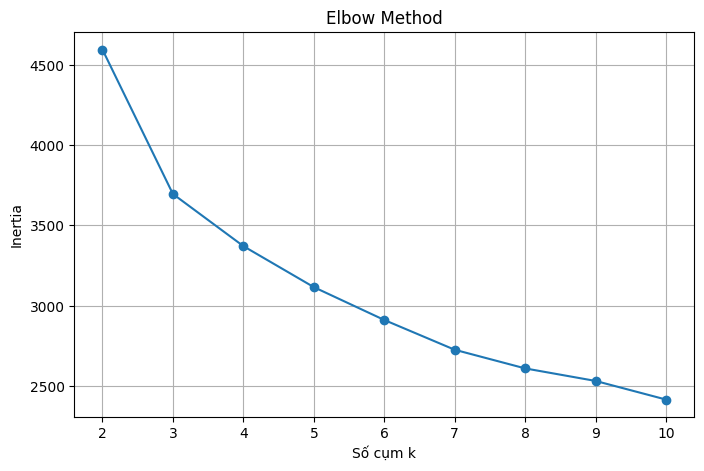

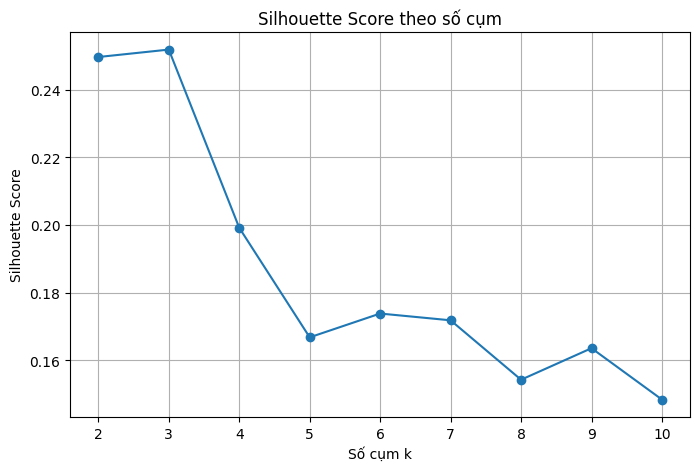

k tốt nhất theo Silhouette: 3


In [22]:
plt.figure(figsize=(8, 5))
plt.plot(evaluation_df["k"], evaluation_df["inertia"], marker="o")
plt.xlabel("Số cụm k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(evaluation_df["k"], evaluation_df["silhouette_score"], marker="o")
plt.xlabel("Số cụm k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score theo số cụm")
plt.grid(True)
plt.show()

best_k = int(evaluation_df.loc[evaluation_df["silhouette_score"].idxmax(), "k"])
print("k tốt nhất theo Silhouette:", best_k)

Từ biểu đồ Elbow, inertia giảm mạnh từ k = 2 đến k = 3, sau đó tiếp tục giảm nhưng tốc độ giảm chậm dần. Điều này cho thấy k = 3 là một điểm gấp khúc tương đối rõ.

Biểu đồ Silhouette cho thấy k = 3 có điểm Silhouette cao nhất, khoảng 0.25. k = 2 cũng gần tương đương, nhưng k = 3 tốt hơn một chút. Từ k = 4 trở đi, Silhouette giảm khá rõ, chứng tỏ việc chia thành nhiều cụm hơn làm chất lượng phân cụm kém đi.

Vì vậy, số cụm phù hợp nhất nên chọn là k = 3. Đây là lựa chọn cân bằng giữa Elbow và Silhouette.

Dùng Elbow:
- Khi muốn quan sát nhanh xu hướng giảm sai số.
- Khi dữ liệu lớn, cần cách đơn giản.
- Khi biểu đồ có điểm gấp rõ ràng.

Dùng Silhouette:
- Khi muốn đánh giá chất lượng cụm rõ hơn.
- Khi cần so sánh nhiều giá trị k.
- Khi muốn biết các cụm có tách biệt tốt không.

Nên dùng cả hai:
- Elbow để xem xu hướng.
- Silhouette để xác nhận k tốt nhất.

## 7. Chạy KMeans chính thức

```python
k_final = best_k
```


In [23]:
k_final = best_k

kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print("Số cầu thủ trong từng cụm:")
display(df["Cluster"].value_counts().sort_index())

display(df[["Player", "Nation", "Pos", "Squad", "Age", "Playing Time_Min", "Cluster"]].head(20))

Số cầu thủ trong từng cụm:


Cluster
0    118
1    161
2     90
Name: count, dtype: int64

,Player,Nation,Pos,Squad,Age,Playing Time_Min,Cluster
0,Brenden Aaronson,us USA,"MF,FW",Leeds United,25-205,2301,2
1,Joshua Acheampong,eng ENG,DF,Chelsea,20-010,587,1
2,Tyler Adams,us USA,MF,Bournemouth,27-090,1593,0
3,Tosin Adarabioyo,eng ENG,DF,Chelsea,28-233,795,1
4,Simon Adingra,ci CIV,"MF,FW",Sunderland,24-134,653,1
5,Amine Adli,ma MAR,MF,Bournemouth,26-005,1075,2
6,Emmanuel Agbadou,ci CIV,DF,Wolves,28-332,1101,1
7,Ola Aina,ng NGA,DF,Nottingham Forest,29-219,1588,1
8,Rayan Aït-Nouri,dz ALG,DF,Manchester City,24-343,960,1
9,Kristoffer Ajer,no NOR,DF,Brentford,28-028,1729,1


## 8. Phân tích đặc điểm từng cụm

In [24]:
cluster_profile = df.groupby("Cluster")[feature_cols].mean().round(2)

display(cluster_profile)

print("Số lượng cầu thủ theo cụm:")
display(df["Cluster"].value_counts().sort_index())

,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Standard_Sh/90,Standard_SoT/90,Standard_G/Sh,Performance_Crs,Performance_Int,Performance_TklW,Performance_CrdY,Performance_CrdR,Performance_Fls,Performance_Fld
Cluster,,,,,,,,,,,,,,,,,
0,30.88,27.68,2436.92,27.08,0.07,0.06,0.13,0.82,0.24,0.08,43.90,27.77,31.66,5.67,0.23,29.22,25.28
1,19.55,11.72,1073.32,11.93,0.07,0.08,0.14,0.99,0.30,0.06,19.48,9.57,12.11,2.09,0.06,12.07,10.39
2,28.87,20.94,1852.74,20.58,0.32,0.15,0.47,2.31,0.86,0.13,46.90,8.56,13.73,3.04,0.06,23.32,27.48


Số lượng cầu thủ theo cụm:


Cluster
0    118
1    161
2     90
Name: count, dtype: int64

In [25]:
important_display_cols = [
    "Player", "Nation", "Pos", "Squad", "Age", "Playing Time_Min",
    "Per 90 Minutes_Gls", "Per 90 Minutes_Ast", "Per 90 Minutes_G+A",
    "Standard_Sh/90", "Standard_SoT/90",
    "Performance_Int", "Performance_TklW",
    "Cluster"
]

important_display_cols = [col for col in important_display_cols if col in df.columns]

for c in sorted(df["Cluster"].unique()):
    print(f"===== CỤM {c} =====")
    display(df[df["Cluster"] == c][important_display_cols].head(10))

===== CỤM 0 =====


,Player,Nation,Pos,Squad,Age,Playing Time_Min,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Standard_Sh/90,Standard_SoT/90,Performance_Int,Performance_TklW,Cluster
2,Tyler Adams,us USA,MF,Bournemouth,27-090,1593,0.11,0.11,0.23,0.51,0.34,27,20,0
12,Omar Alderete,py PAR,DF,Sunderland,29-140,2776,0.03,0.03,0.06,0.78,0.29,36,18,0
13,Ethan Ampadu,wls WAL,MF,Leeds United,25-243,2939,0.03,0.03,0.06,0.80,0.18,50,45,0
14,Joachim Andersen,dk DEN,DF,Fulham,29-349,2875,0.00,0.03,0.03,0.50,0.13,34,26,0
15,Elliot Anderson,eng ENG,MF,Nottingham Forest,23-190,3177,0.11,0.06,0.17,1.22,0.28,38,57,0
16,André,br BRA,MF,Wolves,24-303,2582,0.03,0.00,0.03,0.49,0.03,23,39,0
25,Carlos Baleba,cm CMR,MF,Brighton,22-132,1539,0.00,0.00,0.00,1.05,0.06,28,20,0
26,Daniel Ballard,nir NIR,DF,Sunderland,26-235,2149,0.08,0.00,0.08,1.09,0.38,20,17,0
30,Calvin Bassey,ng NGA,DF,Fulham,26-135,2354,0.04,0.00,0.04,0.46,0.04,19,28,0
32,Rodrigo Bentancur,uy URU,MF,Tottenham Hotspur,28-324,1712,0.05,0.05,0.11,0.68,0.16,33,33,0


===== CỤM 1 =====


,Player,Nation,Pos,Squad,Age,Playing Time_Min,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Standard_Sh/90,Standard_SoT/90,Performance_Int,Performance_TklW,Cluster
1,Joshua Acheampong,eng ENG,DF,Chelsea,20-010,587,0.15,0.00,0.15,0.46,0.31,11,7,1
3,Tosin Adarabioyo,eng ENG,DF,Chelsea,28-233,795,0.00,0.00,0.00,0.23,0.00,9,6,1
4,Simon Adingra,ci CIV,"MF,FW",Sunderland,24-134,653,0.14,0.00,0.14,0.83,0.28,2,8,1
6,Emmanuel Agbadou,ci CIV,DF,Wolves,28-332,1101,0.00,0.00,0.00,0.82,0.25,14,21,1
7,Ola Aina,ng NGA,DF,Nottingham Forest,29-219,1588,0.00,0.00,0.00,0.68,0.06,26,21,1
8,Rayan Aït-Nouri,dz ALG,DF,Manchester City,24-343,960,0.00,0.19,0.19,0.94,0.19,13,20,1
9,Kristoffer Ajer,no NOR,DF,Brentford,28-028,1729,0.00,0.05,0.05,0.52,0.16,13,22,1
10,Nathan Aké,nl NED,DF,Manchester City,31-086,619,0.00,0.00,0.00,0.87,0.15,5,6,1
11,Carlos Alcaraz,ar ARG,MF,Everton,23-166,682,0.00,0.13,0.13,2.51,0.66,2,8,1
18,Jhon Arias,co COL,"FW,MF",Wolves,28-236,1124,0.08,0.00,0.08,1.28,0.24,7,27,1


===== CỤM 2 =====


,Player,Nation,Pos,Squad,Age,Playing Time_Min,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Standard_Sh/90,Standard_SoT/90,Performance_Int,Performance_TklW,Cluster
0,Brenden Aaronson,us USA,"MF,FW",Leeds United,25-205,2301,0.16,0.20,0.35,1.68,0.63,17,26,2
5,Amine Adli,ma MAR,MF,Bournemouth,26-005,1075,0.25,0.08,0.33,1.67,0.75,5,16,2
17,Jaidon Anthony,eng ENG,MF,Burnley,26-165,2548,0.28,0.07,0.35,1.84,0.78,16,21,2
21,Tolu Arokodare,ng NGA,FW,Wolves,25-173,1375,0.20,0.07,0.26,2.88,0.98,5,3,2
22,Yasin Ayari,se SWE,MF,Brighton,22-221,1920,0.14,0.14,0.28,1.92,0.47,25,25,2
28,Harvey Barnes,eng ENG,"FW,MF",Newcastle United,28-157,1847,0.34,0.00,0.34,2.63,0.97,3,5,2
29,Thierno Barry,fr FRA,FW,Everton,23-206,1813,0.40,0.00,0.40,1.84,0.69,5,4,2
35,Beto,gw GNB,FW,Everton,28-104,1489,0.54,0.06,0.60,2.54,1.03,1,5,2
43,Jarrod Bowen,eng ENG,"MF,FW",West Ham United,29-146,3223,0.22,0.28,0.50,2.12,0.73,27,27,2
46,Brian Brobbey,nl NED,FW,Sunderland,24-103,1791,0.30,0.05,0.35,1.56,0.80,0,2,2


## 9. Trực quan hóa bằng PCA 2D

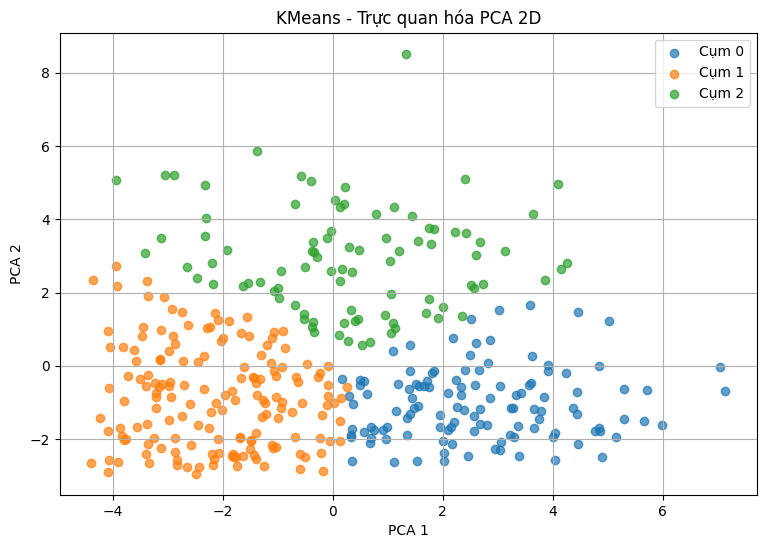

In [26]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X)

df["PCA1"] = X_pca_2d[:, 0]
df["PCA2"] = X_pca_2d[:, 1]

plt.figure(figsize=(9, 6))

for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == c]
    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=f"Cụm {c}",
        alpha=0.7
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans - Trực quan hóa PCA 2D")
plt.legend()
plt.grid(True)
plt.show()

## 10. Trực quan hóa bằng PCA 3D

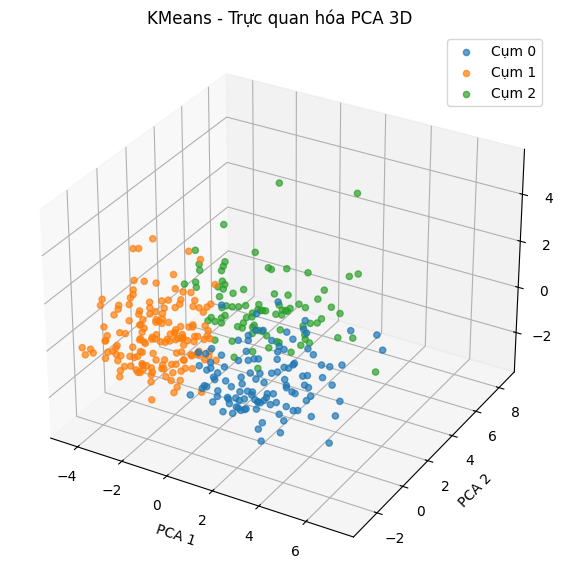

In [27]:
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X)

df["PCA1_3D"] = X_pca_3d[:, 0]
df["PCA2_3D"] = X_pca_3d[:, 1]
df["PCA3_3D"] = X_pca_3d[:, 2]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == c]
    ax.scatter(
        subset["PCA1_3D"],
        subset["PCA2_3D"],
        subset["PCA3_3D"],
        label=f"Cụm {c}",
        alpha=0.7
    )

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("KMeans - Trực quan hóa PCA 3D")
ax.legend()
plt.show()

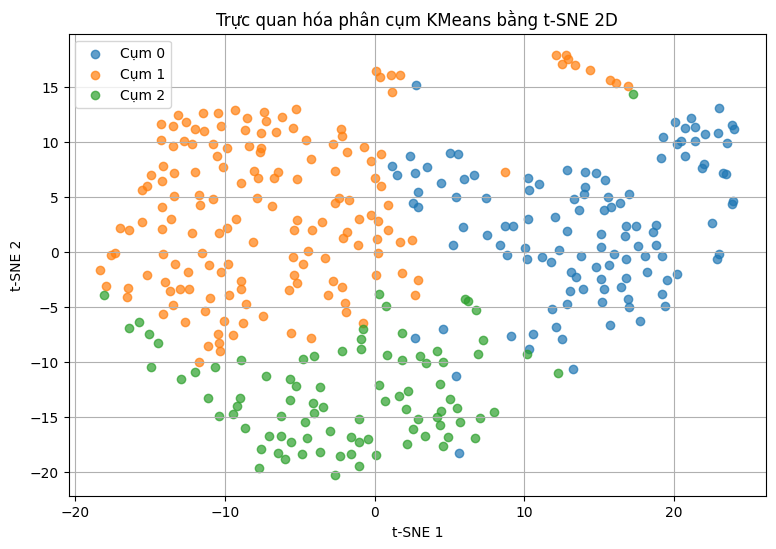

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X)

df["TSNE1"] = X_tsne[:, 0]
df["TSNE2"] = X_tsne[:, 1]

plt.figure(figsize=(9, 6))

for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == c]
    plt.scatter(
        subset["TSNE1"],
        subset["TSNE2"],
        label=f"Cụm {c}",
        alpha=0.7
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Trực quan hóa phân cụm KMeans bằng t-SNE 2D")
plt.legend()
plt.grid(True)
plt.show()

t-SNE được sử dụng để trực quan hóa dữ liệu nhiều chiều xuống không gian 2 chiều. 
Khác với PCA là phương pháp tuyến tính, t-SNE có khả năng thể hiện tốt hơn các cấu trúc phi tuyến trong dữ liệu. 
Biểu đồ t-SNE giúp quan sát trực quan xem các cụm KMeans có tách biệt rõ ràng hay bị chồng lấn với nhau.

> Nhóm sử dụng thuật toán KMeans để phân cụm cầu thủ dựa trên các tiêu chí về thời lượng thi đấu, khả năng ghi bàn, kiến tạo, dứt điểm, hỗ trợ phòng ngự và kỷ luật. Trước khi phân cụm, dữ liệu được chuẩn hóa bằng StandardScaler nhằm đảm bảo các biến có thang đo khác nhau không làm sai lệch khoảng cách Euclid. Nhóm loại bỏ thủ môn và các cầu thủ thi đấu dưới 450 phút để kết quả phân cụm ổn định hơn. Số cụm được đánh giá bằng Elbow Method và Silhouette Score. Cuối cùng, PCA được sử dụng để giảm chiều dữ liệu xuống 2D và 3D nhằm trực quan hóa kết quả phân cụm.
